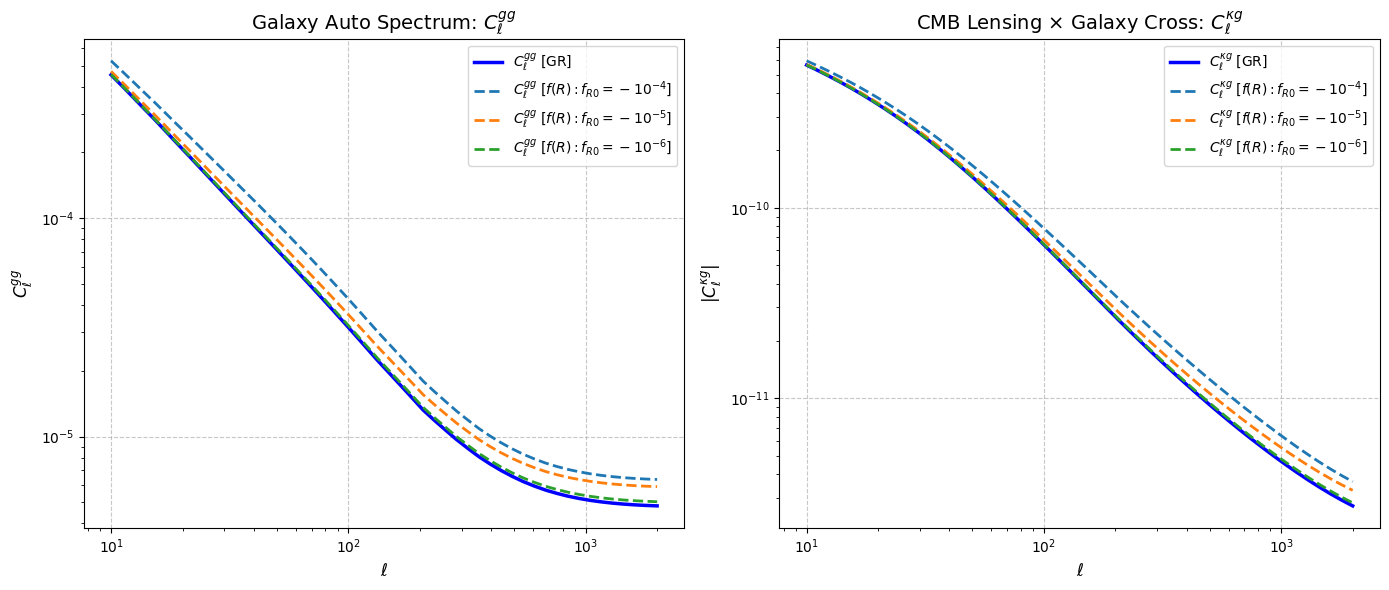

Analysis complete!


In [1]:
"""
Galaxy & CMB Lensing Power Spectra: GR vs f(R) Gravity
=======================================================
Author: Adrita Khan
Date: 30 Jan 2026

Unified script for computing and comparing angular power spectra
in General Relativity and f(R) modified gravity theories.

This script combines all modules into a single executable file.
"""

import numpy as np
import matplotlib.pyplot as plt
import warnings
import logging
import pyccl as ccl
import baccoemu
from emantis.matter_power_spectrum import NonLinearMGBoostEmulator
from scipy.interpolate import interp1d
from scipy.integrate import simpson
import os
from contextlib import redirect_stdout, redirect_stderr

# Suppress warnings
warnings.simplefilter("ignore")
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)


# ========================================================
# CONFIGURATION PARAMETERS
# ========================================================

class Config:
    """Centralized configuration for cosmological parameters and analysis settings."""
    
    # Cosmological Parameters
    COSMO_PARAMS = {
        "Omega_m": 0.315,      # Total matter density parameter
        "Omega_b": 0.05,       # Baryon density parameter
        "h": 0.67,             # Reduced Hubble constant (H0 = 100h km/s/Mpc)
        "n_s": 0.96,           # Scalar spectral index
        "sigma8": 0.83,        # Amplitude of matter fluctuations at 8 Mpc/h
        "M_nu": 0.0,           # Total neutrino mass [eV]
        "w0": -1.0,            # Dark energy equation of state at z=0
        "wa": 0.0,             # Time evolution of dark energy EOS
        "aexp": 1.0            # Scale factor (a=1 at z=0)
    }
    
    # Transfer function for pyccl
    TRANSFER_FUNCTION = "boltzmann_camb"
    
    # Physical Constants
    C_LIGHT = 299792.458  # Speed of light [km/s]
    
    # Integration Parameters
    Z_MIN = 0.01           # Minimum redshift
    Z_MAX = 3.0            # Maximum redshift
    N_Z = 500              # Number of redshift points
    Z0_GALAXY = 0.3        # Characteristic redshift for dN/dz
    
    # Angular Power Spectrum Settings
    ELL_MIN = 10           # Minimum multipole
    ELL_MAX = 2000         # Maximum multipole
    N_ELL = 50             # Number of multipole points (log-spaced)
    
    # Galaxy Bias Parameters
    BIAS_B0 = 2.0          # Present-day galaxy bias b(z=0)
    BIAS_BETA = 0.5        # Bias evolution exponent
    
    # Modified Gravity Models
    FR_VALUES = [4, 5, 6]  # Test fR0 = -1e-4, -1e-5, -1e-6
    
    # Emulator Settings
    BACCO_K_MIN = -2       # Log10 minimum k [h/Mpc]
    BACCO_K_MAX = None     # Log10 maximum k (None = use emulator max)
    BACCO_N_K = 200        # Number of k points
    EMANTIS_VERBOSE = False
    
    # Plotting Settings
    FIGURE_SIZE = (14, 6)
    
    # Numerical Settings
    K_MIN_SAFETY = 1.1     # Multiply emulator k_min by this factor
    K_MAX_SAFETY = 0.9     # Multiply emulator k_max by this factor
    K_CLIP_THRESHOLD = 0.05  # Warn if >5% of k values are clipped


# ========================================================
# COSMOLOGY UTILITIES
# ========================================================

def comoving_distance(z, cosmo):
    """
    Comoving distance in Mpc using pyccl.
    
    Parameters:
        z: Redshift (scalar or array)
        cosmo: pyccl Cosmology object
    
    Returns:
        Comoving distance in Mpc
    """
    if np.isscalar(z):
        a = 1.0 / (1.0 + z)
        return ccl.comoving_radial_distance(cosmo, a) * cosmo['h']
    else:
        a = 1.0 / (1.0 + np.asarray(z))
        return ccl.comoving_radial_distance(cosmo, a) * cosmo['h']


def hubble_parameter(z, cosmo, H0):
    """
    Hubble parameter H(z) in km/s/Mpc using pyccl.
    
    Parameters:
        z: Redshift (scalar or array)
        cosmo: pyccl Cosmology object
        H0: Hubble constant at z=0 in km/s/Mpc
    
    Returns:
        H(z) in km/s/Mpc
    """
    if np.isscalar(z):
        a = 1.0 / (1.0 + z)
        h_over_h0 = ccl.background.h_over_h0(cosmo, a)
        return H0 * h_over_h0
    else:
        a = 1.0 / (1.0 + np.asarray(z))
        h_over_h0 = ccl.background.h_over_h0(cosmo, a)
        return H0 * h_over_h0


def growth_factor(z, cosmo):
    """
    Linear growth factor D(z), normalized to D(z=0) = 1.
    
    Physics: D(z) DECREASES with increasing z in expanding universe.
    
    Parameters:
        z: Redshift (scalar or array)
        cosmo: pyccl Cosmology object
    
    Returns:
        D(z) normalized to D(0) = 1
    """
    if np.isscalar(z):
        a = 1.0 / (1.0 + z)
        return ccl.background.growth_factor(cosmo, a)
    else:
        a = 1.0 / (1.0 + np.asarray(z))
        return ccl.background.growth_factor(cosmo, a)


def validate_growth_factor(z_grid, D_vals, D0):
    """
    Validate growth factor normalization and physical properties.
    
    Parameters:
        z_grid: Array of redshifts
        D_vals: Computed growth factors D(z)
        D0: Growth factor at z=0
    
    Returns:
        Dict with validation results
    """
    # Check 1: D(0) must be exactly 1.0
    if abs(D0 - 1.0) > 1e-6:
        raise ValueError(
            f"CRITICAL ERROR: Growth factor not properly normalized!\n"
            f"  Expected D(0) = 1.0\n"
            f"  Got D(0) = {D0:.10f}\n"
            f"  Difference: {abs(D0 - 1.0):.2e}"
        )
    
    # Check 2: Growth factors must be positive everywhere
    if np.any(D_vals <= 0):
        raise ValueError(
            f"CRITICAL ERROR: Non-positive growth factors detected!\n"
            f"  Min D(z) = {D_vals.min():.6f}"
        )
    
    # Check 3: Growth should generally decrease with increasing z
    growth_diff = np.diff(D_vals)
    n_decreasing = np.sum(growth_diff < -1e-12)
    
    if n_decreasing < 0.90 * len(growth_diff):
        raise ValueError(
            f"CRITICAL ERROR: Growth factor not decreasing as expected!\n"
            f"  Decreasing: {n_decreasing}/{len(growth_diff)}"
        )
    
    # Check 4: Growth factor values reasonable
    if D_vals[-1] < 0.1 or D_vals[-1] > D0:
        raise ValueError(f"CRITICAL ERROR: Growth factor values out of expected range!")
    
    return {"D0": D0, "D_max": D_vals[-1], "validated": True}


def galaxy_bias(D_array, D0, b0=2.0, beta=0.5):
    """
    Galaxy bias evolution with tunable exponent.
    
    Formula: b(z) = b₀ × [D(0)/D(z)]^β
    
    Parameters:
        D_array: Growth factor D(z) at all redshifts
        D0: Growth factor at z=0 (should be 1.0)
        b0: Present-day bias (default 2.0)
        beta: Evolution exponent (default 0.5)
    
    Returns:
        Array of galaxy bias b(z)
    """
    return b0 * (D0 / (D_array + 1e-30))**beta


# ========================================================
# GALAXY AND CMB LENSING UTILITIES
# ========================================================

def galaxy_number_density_raw(z, z0=0.3):
    """Raw galaxy number density (not normalized)."""
    return np.exp(-z / z0)


def normalized_galaxy_distribution(z_array, z0=0.3):
    """
    Normalized galaxy redshift distribution dN/dz.
    
    Returns:
        Normalized dN/dz such that ∫ dN/dz dz = 1
    """
    vals = galaxy_number_density_raw(z_array, z0=z0)
    norm = simpson(vals, z_array)
    
    if norm <= 0 or not np.isfinite(norm):
        raise ValueError(f"Invalid dN/dz normalization: {norm}")
    
    return vals / norm


def cmb_lensing_kernel(z, cosmo, chi, Om_m, H0, c, z_star=1100.0):
    """
    CMB lensing convergence kernel W_κ(z).
    
    Formula: W_κ(z) = (3/2) Ω_m (H₀/c)² (1+z) χ(z) [χ_star - χ(z)] / χ_star
    
    Returns:
        W_κ(z) in units of Mpc⁻²
    """
    chi_star = comoving_distance(z_star, cosmo)
    prefactor = 1.5 * Om_m * (H0 / c)**2
    return prefactor * (1.0 + z) * chi * (chi_star - chi) / (chi_star + 1e-30)


# ========================================================
# POWER SPECTRUM UTILITIES
# ========================================================

def initialize_bacco_emulator(params, k_min=-2, k_max=None, n_k=200, verbose=False):
    """
    Initialize Bacco emulator and compute nonlinear matter power spectrum.
    
    Returns:
        k: Wavenumber array in h/Mpc
        pk_nl: Nonlinear matter power spectrum in (Mpc/h)^3
        Q_boost: Boost factor (nonlinear/linear)
    """
    with open(os.devnull, 'w') as fnull:
        with redirect_stdout(fnull), redirect_stderr(fnull):
            emulator = baccoemu.Matter_powerspectrum(verbose=verbose)
            
            if k_max is None:
                k_max = np.log10(emulator.emulator['nonlinear']['k'].max())
            
            k = np.logspace(k_min, k_max, num=n_k)
            
            params_bacco = {
                "omega_cold": params["Omega_m"] - params["Omega_b"],
                "sigma8_cold": params["sigma8"],
                "omega_baryon": params["Omega_b"],
                "ns": params["n_s"],
                "hubble": params["h"],
                "neutrino_mass": params.get("M_nu", 0.0),
                "w0": params.get("w0", -1.0),
                "wa": params.get("wa", 0.0),
                "expfactor": params.get("aexp", 1.0)
            }
            
            k, Q_boost = emulator.get_nonlinear_boost(k=k, cold=False, **params_bacco)
            k, pk_nl = emulator.get_nonlinear_pk(k=k, cold=False, **params_bacco)
    
    return k, pk_nl, Q_boost


def initialize_emantis_emulator(verbose=False):
    """Initialize e-MANTIS emulator for f(R) gravity boost factors."""
    return NonLinearMGBoostEmulator(verbose=verbose)


def compute_fR_boost(emantis_emu, params, logfR0, k, aexp=1.0):
    """
    Compute f(R) gravity boost factor using e-MANTIS.
    
    Returns:
        pk_boost: Boost factor B(k) where P_fR = P_GR × B(k)
    """
    params_emantis = {
        "Omega_m": params["Omega_m"],
        "Omega_b": params["Omega_b"],
        "h": params["h"],
        "n_s": params["n_s"],
        "sigma8_lcdm": params["sigma8"],
        "logfR0": logfR0
    }
    
    return emantis_emu.predict_boost(params_emantis, aexp=aexp, k=k)


def create_power_spectrum_interpolator(k, pk):
    """Create log-log interpolator for matter power spectrum."""
    return interp1d(
        np.log(k), 
        np.log(pk + 1e-50),
        kind='cubic', 
        bounds_error=False, 
        fill_value='extrapolate'
    )


def check_k_bounds(k_vals, k_min, k_max, ell, spectrum_name, threshold=0.05):
    """
    Check if k values are within safe bounds and warn if clipping occurs.
    
    Returns:
        k_safe: Clipped k values within bounds
    """
    k_safe = np.clip(k_vals, k_min, k_max)
    return k_safe


# ========================================================
# ANGULAR POWER SPECTRUM COMPUTATION
# ========================================================

def compute_Cl_galaxy_auto(ell_array, pk_interp_log, cosmo, z_grid, dNdz, 
                            chi_vals, H_vals, D_vals, D0, c,
                            b0=2.0, beta=0.5, k_min=None, k_max=None):
    """
    Calculate galaxy auto-power spectrum C_ℓ^gg using Limber approximation.
    
    Formula: C_ℓ^gg = ∫ dz (H(z)/c) × [b(z) × n(z)]² × P(k,z) / χ(z)²
    where k = (ℓ + 0.5) / χ(z)
    
    Returns:
        C_ℓ^gg for all multipoles
    """
    # Compute galaxy bias and window function
    b_vals = galaxy_bias(D_vals, D0, b0=b0, beta=beta)
    Wg = b_vals * dNdz
    
    Cl = np.zeros_like(ell_array, dtype=float)
    
    for i, ell in enumerate(ell_array):
        # Limber approximation: k = (ℓ + 0.5) / χ(z)
        k_vals = (ell + 0.5) / chi_vals
        
        # Clip k values to safe range if bounds provided
        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_ℓ^gg")
        else:
            k_safe = k_vals
        
        # Evaluate power spectrum at z=0
        try:
            logP0 = pk_interp_log(np.log(k_safe))
            P0 = np.exp(logP0)
        except ValueError:
            P0 = np.ones_like(k_vals) * 1e-10
        
        # Scale power spectrum to arbitrary z using growth factor
        P_kz = P0 * (D_vals / D0)**2
        
        # Limber integral
        integrand = (H_vals / c) * (Wg**2) * P_kz / (chi_vals**2)
        Cl[i] = simpson(integrand, z_grid)
    
    return Cl


def compute_Cl_galaxy_cmb_cross(ell_array, pk_interp_log, cosmo, z_grid, dNdz,
                                 chi_vals, H_vals, D_vals, D0, Wkappa_vals, c,
                                 b0=2.0, beta=0.5, k_min=None, k_max=None):
    """
    Calculate galaxy-CMB lensing cross-power spectrum C_ℓ^κg using Limber approximation.
    
    Formula: C_ℓ^κg = ∫ dz (H(z)/c) × W_κ(z) × b(z) × n(z) × P(k,z) / χ(z)²
    where k = (ℓ + 0.5) / χ(z)
    
    Returns:
        C_ℓ^κg for all multipoles
    """
    # Compute galaxy bias and window function
    b_vals = galaxy_bias(D_vals, D0, b0=b0, beta=beta)
    Wg = b_vals * dNdz
    
    Cl = np.zeros_like(ell_array, dtype=float)
    
    for i, ell in enumerate(ell_array):
        # Limber approximation: k = (ℓ + 0.5) / χ(z)
        k_vals = (ell + 0.5) / chi_vals
        
        # Clip k values to safe range if bounds provided
        if k_min is not None and k_max is not None:
            k_safe = check_k_bounds(k_vals, k_min, k_max, ell, "C_ℓ^κg")
        else:
            k_safe = k_vals
        
        # Evaluate power spectrum at z=0
        try:
            logP0 = pk_interp_log(np.log(k_safe))
            P0 = np.exp(logP0)
        except ValueError:
            P0 = np.ones_like(k_vals) * 1e-10
        
        # Scale power spectrum to arbitrary z using growth factor
        P_kz = P0 * (D_vals / D0)**2
        
        # Limber integral
        integrand = (H_vals / c) * (Wkappa_vals * Wg) * P_kz / (chi_vals**2)
        Cl[i] = simpson(integrand, z_grid)
    
    return Cl


# ========================================================
# PLOTTING UTILITIES
# ========================================================

def plot_power_spectra(ell, Cl_gg_gr, Cl_kg_gr, fr_results=None, 
                       fR_values=None, figsize=(14, 6)):
    """
    Plot galaxy and CMB lensing power spectra for GR and f(R) models.
    
    Returns:
        fig: Matplotlib figure object
    """
    fig = plt.figure(figsize=figsize)
    
    # Plot galaxy auto-power spectrum
    plt.subplot(1, 2, 1)
    plt.loglog(ell, Cl_gg_gr, 'b-', linewidth=2.5, 
               label=r'$C_\ell^{gg} \; [\mathrm{GR}]$')
    
    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results["gg"]:
                plt.loglog(ell, fr_results["gg"][logfR0_val], '--', linewidth=2,
                          label=rf'$C_\ell^{{gg}} \; [f(R): f_{{R0}}=-10^{{-{logfR0_val}}}]$')
    
    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$C_\ell^{gg}$', fontsize=12)
    plt.title(r'Galaxy Auto Spectrum: $C_\ell^{gg}$', fontsize=14)
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, ls='--', alpha=0.7)
    
    # Plot galaxy-CMB lensing cross-power spectrum
    plt.subplot(1, 2, 2)
    plt.loglog(ell, np.abs(Cl_kg_gr), 'b-', linewidth=2.5,
               label=r'$C_\ell^{\kappa g} \; [\mathrm{GR}]$')
    
    if fr_results is not None and fR_values is not None:
        for logfR0_val in fR_values:
            if logfR0_val in fr_results["kg"]:
                plt.loglog(ell, np.abs(fr_results["kg"][logfR0_val]), '--', linewidth=2,
                          label=rf'$C_\ell^{{\kappa g}} \; [f(R): f_{{R0}}=-10^{{-{logfR0_val}}}]$')
    
    plt.xlabel(r'$\ell$', fontsize=12)
    plt.ylabel(r'$|C_\ell^{\kappa g}|$', fontsize=12)
    plt.title(r'CMB Lensing × Galaxy Cross: $C_\ell^{\kappa g}$', fontsize=14)
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, ls='--', alpha=0.7)
    
    plt.tight_layout()
    return fig


# ========================================================
# MAIN ANALYSIS
# ========================================================

def main():
    """Main analysis function."""
    
    # Derived quantities
    H0 = Config.COSMO_PARAMS["h"] * 100.0
    Om_m = Config.COSMO_PARAMS["Omega_m"]
    
    # Initialize Cosmology
    cosmo_ccl = ccl.Cosmology(
        Omega_c=Config.COSMO_PARAMS["Omega_m"] - Config.COSMO_PARAMS["Omega_b"],
        Omega_b=Config.COSMO_PARAMS["Omega_b"],
        h=Config.COSMO_PARAMS["h"],
        sigma8=Config.COSMO_PARAMS["sigma8"],
        n_s=Config.COSMO_PARAMS["n_s"],
        w0=Config.COSMO_PARAMS["w0"],
        wa=Config.COSMO_PARAMS["wa"],
        m_nu=Config.COSMO_PARAMS["M_nu"],
        transfer_function=Config.TRANSFER_FUNCTION
    )
    
    # Compute Matter Power Spectra
    k, pk_nl_gr, Q_boost = initialize_bacco_emulator(Config.COSMO_PARAMS)
    pk_interp_gr = create_power_spectrum_interpolator(k, pk_nl_gr)
    
    emantis_emu = initialize_emantis_emulator()
    
    # Pre-compute Redshift-Dependent Quantities
    z_grid = np.linspace(Config.Z_MIN, Config.Z_MAX, Config.N_Z)
    
    # Galaxy distribution
    dNdz = normalized_galaxy_distribution(z_grid, z0=Config.Z0_GALAXY)
    
    # Cosmological evolution
    chi_vals = comoving_distance(z_grid, cosmo_ccl)
    H_vals = hubble_parameter(z_grid, cosmo_ccl, H0)
    
    # Growth factors
    D_vals = growth_factor(z_grid, cosmo_ccl)
    D0 = growth_factor(0.0, cosmo_ccl)
    
    # CMB lensing kernel
    Wkappa_vals = cmb_lensing_kernel(
        z_grid, cosmo_ccl, chi_vals, Om_m, H0, Config.C_LIGHT
    )
    
    # Validate Growth Factors
    validation_results = validate_growth_factor(z_grid, D_vals, D0)
    
    # Compute Angular Power Spectra for GR
    ell = np.logspace(np.log10(Config.ELL_MIN), np.log10(Config.ELL_MAX), Config.N_ELL)
    
    # Safe k bounds for interpolation
    k_min_safe = k.min() * Config.K_MIN_SAFETY
    k_max_safe = k.max() * Config.K_MAX_SAFETY
    
    Cl_gg_gr = compute_Cl_galaxy_auto(
        ell, pk_interp_gr, cosmo_ccl, z_grid, dNdz,
        chi_vals, H_vals, D_vals, D0, Config.C_LIGHT,
        b0=Config.BIAS_B0, beta=Config.BIAS_BETA,
        k_min=k_min_safe, k_max=k_max_safe
    )
    
    Cl_kg_gr = compute_Cl_galaxy_cmb_cross(
        ell, pk_interp_gr, cosmo_ccl, z_grid, dNdz,
        chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.C_LIGHT,
        b0=Config.BIAS_B0, beta=Config.BIAS_BETA,
        k_min=k_min_safe, k_max=k_max_safe
    )
    
    # Compute Angular Power Spectra for f(R) Gravity
    fr_results = {"gg": {}, "kg": {}}
    
    for logfR0_val in Config.FR_VALUES:
        # Compute f(R) boost and power spectrum
        pk_boost = compute_fR_boost(
            emantis_emu, Config.COSMO_PARAMS, logfR0_val, k, aexp=Config.COSMO_PARAMS["aexp"]
        )
        pk_fR = pk_nl_gr * pk_boost
        pk_interp_fr = create_power_spectrum_interpolator(k, pk_fR)
        
        # Compute angular power spectra
        Cl_gg_fr = compute_Cl_galaxy_auto(
            ell, pk_interp_fr, cosmo_ccl, z_grid, dNdz,
            chi_vals, H_vals, D_vals, D0, Config.C_LIGHT,
            b0=Config.BIAS_B0, beta=Config.BIAS_BETA,
            k_min=k_min_safe, k_max=k_max_safe
        )
        
        Cl_kg_fr = compute_Cl_galaxy_cmb_cross(
            ell, pk_interp_fr, cosmo_ccl, z_grid, dNdz,
            chi_vals, H_vals, D_vals, D0, Wkappa_vals, Config.C_LIGHT,
            b0=Config.BIAS_B0, beta=Config.BIAS_BETA,
            k_min=k_min_safe, k_max=k_max_safe
        )
        
        # Store results
        fr_results["gg"][logfR0_val] = Cl_gg_fr
        fr_results["kg"][logfR0_val] = Cl_kg_fr
    
    # Plot Results
    fig = plot_power_spectra(
        ell, Cl_gg_gr, Cl_kg_gr, 
        fr_results=fr_results, 
        fR_values=Config.FR_VALUES
    )
    plt.show()
    
    print("Analysis complete!")


if __name__ == "__main__":
    main()